# EFL-to-EPL Promotion Strength Bridge

The seasonal strength model defines a scalar team-strength measure

$$
q_{i,t}
=
\frac{
PPG_{i,t}-\overline{PPG}_t
}{
SD(PPG_t)
},
$$

where $q_{i,t}$ measures team $i$'s relative league position within season
$t$.

In the venue-specific state model, this scalar is used as the opponent-strength
input in

$$
\mathbf{x}_{i,v,m}
=
\boldsymbol{\alpha}_{i,v}
+
\boldsymbol{\beta}_{i,v}q_{j(m)}
+
\boldsymbol{\varepsilon}_{i,v,m}.
$$

However, EPL and Championship values of $q$ are standardized separately.
Therefore, a Championship value such as $q=2$ cannot be interpreted directly
as an EPL value of $q=2$.

This notebook constructs an empirical promotion bridge between the two league
scales using historical teams that played in the Championship in season $t$
and the Premier League in season $t+1$.

The objective is not to transform the full venue-specific state vector.
Instead, the bridge provides an EPL-scale initialization for the scalar
opponent-strength variable $q$ when a newly promoted team has no previous
Premier League strength observation.

## 1. Extending the Historical Strength Sample

The main seasonal-state analysis uses the recent five-season data window.
For the promotion bridge, however, a longer historical sample is useful because
only three teams are promoted to the Premier League in each season.

The historical window is therefore extended back to 2014–15 solely for
cross-league calibration.

For each EPL and Championship season, team points per game are calculated from
the raw Football-Data match results and standardized using the same definition
of \(q\) as in the main strength model:

$$
q_{i,t}
=
\frac{
PPG_{i,t}-\overline{PPG}_t
}{
SD(PPG_t)
}.
$$

Using the same definition ensures that the historical observations are
compatible with the more recent strength results.

The longer historical window is used only to estimate the EFL-to-EPL bridge;
it does not replace the five-season window used to construct the main
venue-specific team states.

In [36]:
import pandas as pd
import numpy as np
import zipfile
import re
from pathlib import Path


# ============================================================
# A — Compute historical E0/E1 q directly from raw match files
# ============================================================

OLD_ZIP = "data_from_footballdata.zip"


def season_from_filename(filename):
    """
    E0_1415.csv -> 2014-15
    E1_2021.csv -> 2020-21
    """
    
    filename = Path(filename).name

    match = re.fullmatch(
        r"(E[01])_(\d{2})(\d{2})\.csv",
        filename,
        flags=re.I
    )

    if match is None:
        raise ValueError(
            f"Cannot identify season from {filename}"
        )

    return (
        f"20{match.group(2)}-"
        f"{match.group(3)}"
    )


def calculate_strength_q(match_df, season):
    """
    Reproduce the same PPG-based Strength_q used in
    team_strength2.
    """

    df = match_df.copy()

    # Some historical Football-Data files contain
    # a completely blank final row.
    df = df.dropna(
        subset=[
            "HomeTeam",
            "AwayTeam",
            "FTHG",
            "FTAG"
        ]
    ).copy()

    # Points from the home-team perspective
    home_points = np.select(
        [
            df["FTHG"] > df["FTAG"],
            df["FTHG"] == df["FTAG"]
        ],
        [3, 1],
        default=0
    )

    # Points from the away-team perspective
    away_points = np.select(
        [
            df["FTAG"] > df["FTHG"],
            df["FTHG"] == df["FTAG"]
        ],
        [3, 1],
        default=0
    )

    home = pd.DataFrame({
        "Season": season,
        "Team": df["HomeTeam"].astype(str).str.strip(),
        "Points": home_points
    })

    away = pd.DataFrame({
        "Season": season,
        "Team": df["AwayTeam"].astype(str).str.strip(),
        "Points": away_points
    })

    long_df = pd.concat(
        [home, away],
        ignore_index=True
    )

    # Same season-level calculation as team_strength2
    strength = (
        long_df
        .groupby(
            ["Season", "Team"],
            as_index=False
        )
        .agg(
            Total_Points=("Points", "sum"),
            Matches_Played=("Points", "size")
        )
    )

    strength["PPG"] = (
        strength["Total_Points"]
        / strength["Matches_Played"]
    )

    strength["Mean_PPG"] = (
        strength.groupby("Season")["PPG"]
        .transform("mean")
    )

    strength["Std_PPG"] = (
        strength.groupby("Season")["PPG"]
        .transform(
            lambda x: x.std(ddof=0)
        )
    )

    strength["Strength_q"] = (
        strength["PPG"]
        - strength["Mean_PPG"]
    ) / strength["Std_PPG"]

    return strength

In [37]:
historical_strength = {
    "E0": [],
    "E1": []
}


with zipfile.ZipFile(OLD_ZIP, "r") as archive:

    for filename in archive.namelist():

        base_name = Path(filename).name

        if not (
            base_name.startswith("E0_")
            or base_name.startswith("E1_")
        ):
            continue

        league = base_name[:2]

        season = season_from_filename(
            base_name
        )

        with archive.open(filename) as file:

            match_df = pd.read_csv(
                file,
                low_memory=False
            )

        strength = calculate_strength_q(
            match_df,
            season
        )

        historical_strength[
            league
        ].append(strength)


old_epl_q = pd.concat(
    historical_strength["E0"],
    ignore_index=True
)

old_efl_q = pd.concat(
    historical_strength["E1"],
    ignore_index=True
)


print("Historical EPL:")
display(old_epl_q.head())

print("\nHistorical Championship:")
display(old_efl_q.head())

Historical EPL:


,Season,Team,Total_Points,Matches_Played,PPG,Mean_PPG,Std_PPG,Strength_q
0,2019-20,Arsenal,56,38,1.473684,1.378947,0.455909,0.207798
1,2019-20,Aston Villa,35,38,0.921053,1.378947,0.455909,-1.004355
2,2019-20,Bournemouth,34,38,0.894737,1.378947,0.455909,-1.062077
3,2019-20,Brighton,41,38,1.078947,1.378947,0.455909,-0.658026
4,2019-20,Burnley,54,38,1.421053,1.378947,0.455909,0.092354



Historical Championship:


,Season,Team,Total_Points,Matches_Played,PPG,Mean_PPG,Std_PPG,Strength_q
0,2014-15,Birmingham,63,46,1.369565,1.356884,0.364842,0.034758
1,2014-15,Blackburn,67,46,1.456522,1.356884,0.364842,0.273098
2,2014-15,Blackpool,26,46,0.565217,1.356884,0.364842,-2.169890
3,2014-15,Bolton,51,46,1.108696,1.356884,0.364842,-0.680263
4,2014-15,Bournemouth,90,46,1.956522,1.356884,0.364842,1.643556


## 2. Combining Historical and Current Strength Estimates

The historical strength estimates are combined with the $q$ values produced
by the main team-strength workflow.

After combination, both leagues contain season-level relative-strength
observations from 2014–15 through 2025–26.

This produces a common historical database from which promotion transitions can
be identified while preserving the original within-league standardization of
$q$.

In [38]:
# ============================================================
# STEP 1 — Combine old and current q
# ============================================================

CURRENT_FILE = "team_strength_all_results.xlsx"

current_epl_q = pd.read_excel(
    CURRENT_FILE,
    sheet_name="E0_Team_Strength_q"
)

current_efl_q = pd.read_excel(
    CURRENT_FILE,
    sheet_name="E1_Team_Strength_q"
)


epl_q = pd.concat(
    [
        old_epl_q[["Season", "Team", "Strength_q"]],
        current_epl_q[["Season", "Team", "Strength_q"]]
    ],
    ignore_index=True
)

efl_q = pd.concat(
    [
        old_efl_q[["Season", "Team", "Strength_q"]],
        current_efl_q[["Season", "Team", "Strength_q"]]
    ],
    ignore_index=True
)

epl_q = (
    epl_q
    .rename(columns={"Strength_q": "q"})
    .drop_duplicates(["Season", "Team"])
    .sort_values(["Season", "Team"])
    .reset_index(drop=True)
)

efl_q = (
    efl_q
    .rename(columns={"Strength_q": "q"})
    .drop_duplicates(["Season", "Team"])
    .sort_values(["Season", "Team"])
    .reset_index(drop=True)
)

print("EPL seasons:")
print(sorted(epl_q["Season"].unique()))

print("\nEFL seasons:")
print(sorted(efl_q["Season"].unique()))

print("\nEPL rows:", len(epl_q))
print("EFL rows:", len(efl_q))

EPL seasons:
['2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

EFL seasons:
['2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']

EPL rows: 240
EFL rows: 288


## 3. Constructing Promotion Transitions

A promotion transition is defined when the same club appears in the
Championship in season $t$ and in the Premier League in season $t+1$.

For each promoted club, the bridge therefore observes the pair

$$
\left(
q_{i,t}^{EFL},
q_{i,t+1}^{EPL}
\right).
$$

These observations act as empirical links between the two independently
standardized league-strength scales.

Across the available historical window, 11 promotion cohorts are observed,
with three promoted clubs in each cohort, giving

$$
11\times3=33
$$

cross-league transitions.

The bridge is estimated from these 33 transitions rather than from the
five-season state-estimation window because its purpose is specifically to
learn the historical relationship between Championship and Premier League
relative strength.

In [39]:
# ============================================================
# STEP 2 — Construct promotion transition pairs
# ============================================================

def next_season(season):
    """
    Example:
    2021-22 -> 2022-23
    """
    start = int(str(season).split("-")[0])
    return f"{start + 1}-{str(start + 2)[-2:]}"


promotion_pairs = []

for efl_season in sorted(efl_q["Season"].unique()):

    epl_season = next_season(efl_season)

    # Skip if following EPL season is unavailable
    if epl_season not in epl_q["Season"].unique():
        continue

    efl_this = (
        efl_q[efl_q["Season"] == efl_season]
        [["Team", "q"]]
    )

    epl_next = (
        epl_q[epl_q["Season"] == epl_season]
        [["Team", "q"]]
    )

    paired = efl_this.merge(
        epl_next,
        on="Team",
        suffixes=("_EFL", "_EPL")
    )

    paired["EFL_Season"] = efl_season
    paired["EPL_Season"] = epl_season

    promotion_pairs.append(paired)


promotion_bridge = pd.concat(
    promotion_pairs,
    ignore_index=True
)

promotion_bridge = promotion_bridge[
    [
        "Team",
        "EFL_Season",
        "q_EFL",
        "EPL_Season",
        "q_EPL"
    ]
]

promotion_bridge["Gap"] = (
    promotion_bridge["q_EPL"]
    - promotion_bridge["q_EFL"]
)

display(promotion_bridge)

print("\nNumber of transitions:",
      len(promotion_bridge))

print("\nTeams per promotion cohort:")
display(
    promotion_bridge.groupby("EPL_Season").size()
)

,Team,EFL_Season,q_EFL,EPL_Season,q_EPL,Gap
0,Bournemouth,2014-15,1.643556,2015-16,-0.641302,-2.284858
1,Norwich,2014-15,1.405215,2015-16,-1.172952,-2.578167
2,Watford,2014-15,1.583970,2015-16,-0.441934,-2.025904
3,Burnley,2015-16,1.950246,2016-17,-0.661554,-2.611800
4,Hull,2015-16,1.324499,2016-17,-0.971657,-2.296156
5,Middlesbrough,2015-16,1.699947,2016-17,-1.281761,-2.981708
6,Brighton,2016-17,1.811066,2017-18,-0.644885,-2.455952
7,Huddersfield,2016-17,1.072274,2017-18,-0.805438,-1.877712
8,Newcastle,2016-17,1.872632,2017-18,-0.430816,-2.303448
9,Cardiff,2017-18,1.621911,2018-19,-0.949914,-2.571825



Number of transitions: 33

Teams per promotion cohort:


EPL_Season
2015-16    3
2016-17    3
2017-18    3
2018-19    3
2019-20    3
2020-21    3
2021-22    3
2022-23    3
2023-24    3
2024-25    3
2025-26    3
dtype: int64

## 4. Exploratory Cross-League Relationship

Before fitting a bridge model, the historical Championship and subsequent EPL
strength values are examined directly.

For each promoted team, define the cross-league change

$$
\Delta_i
=
q_{i,t+1}^{EPL}
-
q_{i,t}^{EFL}.
$$

Because promoted teams are typically among the strongest clubs in the
Championship but become below-average clubs after entering the Premier League,
a substantial negative average gap is expected.

However, the magnitude of this average shift alone does not determine whether
differences among Championship teams remain informative after promotion.
That question is tested explicitly in the following models.

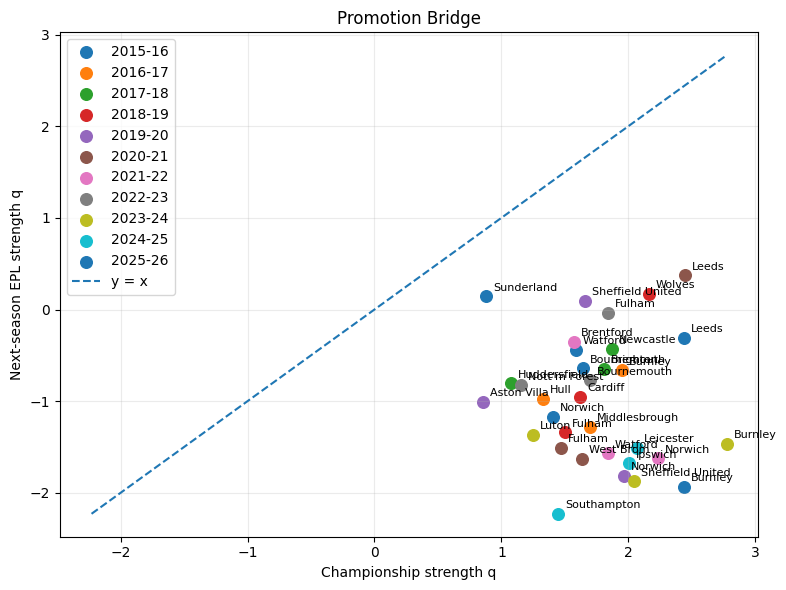

count    33.000000
mean     -2.709564
std       0.851474
min      -4.369840
25%      -3.409023
50%      -2.578167
75%      -2.025904
max      -0.735074
Name: Gap, dtype: float64


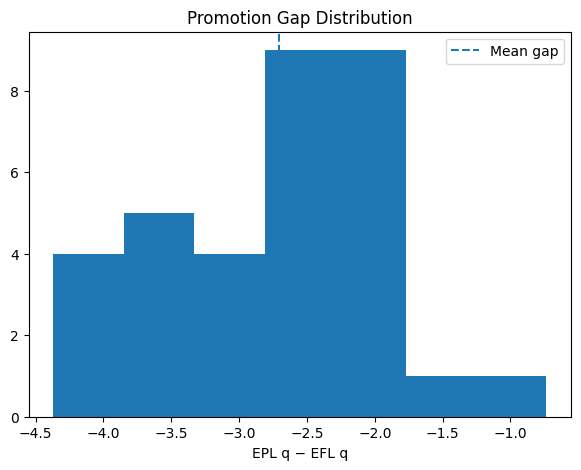

In [40]:
# ============================================================
# STEP 3 — Exploratory plots
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

for season, group in promotion_bridge.groupby("EPL_Season"):

    ax.scatter(
        group["q_EFL"],
        group["q_EPL"],
        s=70,
        label=season
    )

    for _, row in group.iterrows():
        ax.annotate(
            row["Team"],
            (row["q_EFL"], row["q_EPL"]),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8
        )

# y = x reference
low = min(
    promotion_bridge["q_EFL"].min(),
    promotion_bridge["q_EPL"].min()
)

high = max(
    promotion_bridge["q_EFL"].max(),
    promotion_bridge["q_EPL"].max()
)

ax.plot(
    [low, high],
    [low, high],
    linestyle="--",
    label="y = x"
)

ax.set_xlabel("Championship strength q")
ax.set_ylabel("Next-season EPL strength q")
ax.set_title("Promotion Bridge")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


# Gap distribution
print(promotion_bridge["Gap"].describe())

fig, ax = plt.subplots(figsize=(7, 5))

ax.hist(
    promotion_bridge["Gap"],
    bins="auto"
)

ax.axvline(
    promotion_bridge["Gap"].mean(),
    linestyle="--",
    label="Mean gap"
)

ax.set_xlabel("EPL q − EFL q")
ax.set_title("Promotion Gap Distribution")
ax.legend()

plt.show()

## 5. Candidate Bridge Specifications

Two simple cross-league transformations are first considered.

### 5.1 Constant-Shift Bridge

The first specification assumes that promotion produces a common downward
shift while preserving all relative differences among Championship teams:

$$
q_{i,t+1}^{EPL}
=
q_{i,t}^{EFL}
+
\Delta.
$$

The parameter $\Delta$ therefore represents the average change in standardized
league position associated with promotion.

This model imposes a slope of one, meaning that a one-unit difference between
two Championship teams must remain a one-unit difference after entering the
Premier League.

### 5.2 Linear Bridge

The restriction of unit slope is then relaxed:

$$
q_{i,t+1}^{EPL}
=
a+bq_{i,t}^{EFL}
+\varepsilon_i.
$$

Here,

- $a$ captures the overall cross-league level shift;
- $b$ measures how much Championship relative-strength information survives
  after promotion.

If $b\approx1$, Championship differences are largely preserved.

If $0<b<1$, those differences are partially compressed.

If $b\approx0$, Championship $q$ provides little stable information about
next-season EPL relative strength.

In [41]:
# ============================================================
# STEP 4 — Constant-shift bridge
# ============================================================

delta_hat = promotion_bridge["Gap"].mean()

promotion_bridge["Pred_Constant"] = (
    promotion_bridge["q_EFL"]
    + delta_hat
)

promotion_bridge["Residual_Constant"] = (
    promotion_bridge["q_EPL"]
    - promotion_bridge["Pred_Constant"]
)

rmse_constant = np.sqrt(
    np.mean(
        promotion_bridge["Residual_Constant"] ** 2
    )
)

mae_constant = np.mean(
    np.abs(
        promotion_bridge["Residual_Constant"]
    )
)

print(f"Delta = {delta_hat:.4f}")
print(f"RMSE  = {rmse_constant:.4f}")
print(f"MAE   = {mae_constant:.4f}")

Delta = -2.7096
RMSE  = 0.8385
MAE   = 0.6910


a = -0.7688
b = -0.1165
R² = 0.0058
RMSE = 0.6756
MAE  = 0.5700


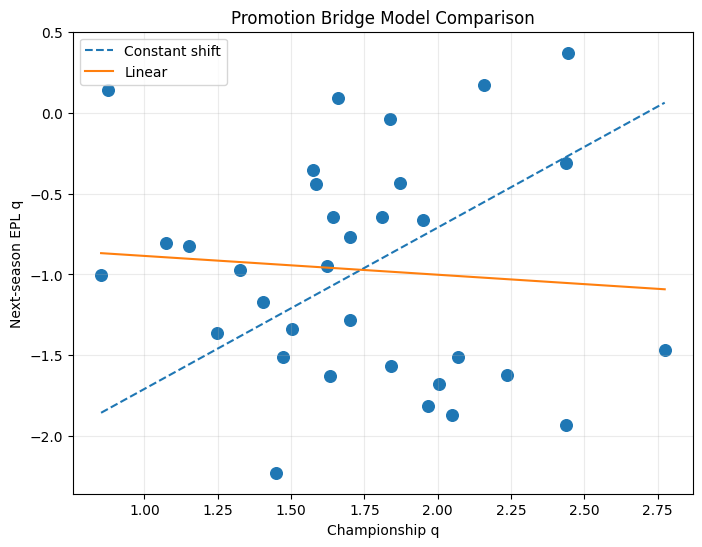

In [42]:
# ============================================================
# STEP 5 — Linear bridge
# ============================================================

X = promotion_bridge[["q_EFL"]]
y = promotion_bridge["q_EPL"]

linear_model = LinearRegression()
linear_model.fit(X, y)

a_hat = linear_model.intercept_
b_hat = linear_model.coef_[0]

promotion_bridge["Pred_Linear"] = (
    linear_model.predict(X)
)

promotion_bridge["Residual_Linear"] = (
    promotion_bridge["q_EPL"]
    - promotion_bridge["Pred_Linear"]
)

rmse_linear = np.sqrt(
    np.mean(
        promotion_bridge["Residual_Linear"] ** 2
    )
)

mae_linear = np.mean(
    np.abs(
        promotion_bridge["Residual_Linear"]
    )
)

r2_linear = linear_model.score(X, y)

print(f"a = {a_hat:.4f}")
print(f"b = {b_hat:.4f}")
print(f"R² = {r2_linear:.4f}")
print(f"RMSE = {rmse_linear:.4f}")
print(f"MAE  = {mae_linear:.4f}")


# Plot both models
x_grid = np.linspace(
    promotion_bridge["q_EFL"].min(),
    promotion_bridge["q_EFL"].max(),
    200
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    promotion_bridge["q_EFL"],
    promotion_bridge["q_EPL"],
    s=70
)

ax.plot(
    x_grid,
    x_grid + delta_hat,
    linestyle="--",
    label="Constant shift"
)

ax.plot(
    x_grid,
    a_hat + b_hat * x_grid,
    label="Linear"
)

ax.set_xlabel("Championship q")
ax.set_ylabel("Next-season EPL q")
ax.set_title("Promotion Bridge Model Comparison")
ax.legend()
ax.grid(alpha=0.25)

plt.show()

## 6. Out-of-Sample Validation and Parameter Stability

In-sample fit is not sufficient for selecting the bridge because only 33
historical promotion transitions are available.

The models are therefore evaluated using
**Leave-One-Promotion-Cohort-Out cross-validation (LOCO-CV)**.

For each fold, all three clubs promoted into the same EPL season are removed
together. The bridge is estimated using the remaining promotion cohorts and is
then used to predict the held-out three clubs.

Holding out the full cohort avoids allowing clubs from the same promotion
season to appear simultaneously in the training and validation samples.

Model performance is evaluated using

$$
RMSE
=
\sqrt{
\frac{1}{N}
\sum_{i=1}^{N}
\left(
q_i^{EPL}-\hat q_i^{EPL}
\right)^2
}
$$

and mean absolute error.

A cohort bootstrap is also used to examine parameter uncertainty while
preserving the three-team structure of each promotion season.

In [43]:
# ============================================================
# STEP 6A — Leave-one-promotion-cohort-out CV
# ============================================================

cv_results = []

cohorts = sorted(
    promotion_bridge["EPL_Season"].unique()
)

for test_cohort in cohorts:

    train = promotion_bridge[
        promotion_bridge["EPL_Season"] != test_cohort
    ]

    test = promotion_bridge[
        promotion_bridge["EPL_Season"] == test_cohort
    ]

    # ----------------------
    # Constant shift
    # ----------------------

    delta_train = (
        train["q_EPL"]
        - train["q_EFL"]
    ).mean()

    pred_constant = (
        test["q_EFL"]
        + delta_train
    )

    # ----------------------
    # Linear
    # ----------------------

    model = LinearRegression()

    model.fit(
        train[["q_EFL"]],
        train["q_EPL"]
    )

    pred_linear = model.predict(
        test[["q_EFL"]]
    )

    for i, (_, row) in enumerate(test.iterrows()):

        cv_results.append({
            "Cohort": test_cohort,
            "Team": row["Team"],
            "True_q_EPL": row["q_EPL"],
            "Pred_Constant": pred_constant.iloc[i],
            "Pred_Linear": pred_linear[i]
        })


cv_results = pd.DataFrame(cv_results)

cv_results["Error_Constant"] = (
    cv_results["True_q_EPL"]
    - cv_results["Pred_Constant"]
)

cv_results["Error_Linear"] = (
    cv_results["True_q_EPL"]
    - cv_results["Pred_Linear"]
)


cv_rmse_constant = np.sqrt(
    np.mean(cv_results["Error_Constant"] ** 2)
)

cv_rmse_linear = np.sqrt(
    np.mean(cv_results["Error_Linear"] ** 2)
)

cv_mae_constant = np.mean(
    np.abs(cv_results["Error_Constant"])
)

cv_mae_linear = np.mean(
    np.abs(cv_results["Error_Linear"])
)


comparison = pd.DataFrame({
    "Model": [
        "Constant shift",
        "Linear"
    ],
    "CV_RMSE": [
        cv_rmse_constant,
        cv_rmse_linear
    ],
    "CV_MAE": [
        cv_mae_constant,
        cv_mae_linear
    ]
})

display(comparison)

,Model,CV_RMSE,CV_MAE
0,Constant shift,0.869016,0.718874
1,Linear,0.724003,0.609317


In [44]:
# ============================================================
# STEP 6B — Cohort bootstrap
# ============================================================

N_BOOT = 5000
rng = np.random.default_rng(42)

cohorts = promotion_bridge[
    "EPL_Season"
].unique()

boot_results = []

for _ in range(N_BOOT):

    sampled_cohorts = rng.choice(
        cohorts,
        size=len(cohorts),
        replace=True
    )

    boot = pd.concat(
        [
            promotion_bridge[
                promotion_bridge["EPL_Season"] == c
            ]
            for c in sampled_cohorts
        ],
        ignore_index=True
    )

    # Constant
    delta_b = (
        boot["q_EPL"]
        - boot["q_EFL"]
    ).mean()

    # Linear
    model = LinearRegression()

    model.fit(
        boot[["q_EFL"]],
        boot["q_EPL"]
    )

    boot_results.append({
        "Delta": delta_b,
        "Intercept": model.intercept_,
        "Slope": model.coef_[0]
    })


boot_results = pd.DataFrame(boot_results)


def ci95(x):
    return np.quantile(x, [0.025, 0.975])


print("Constant shift:")
print("Delta =", round(delta_hat, 4))
print("95% CI =", ci95(boot_results["Delta"]))


print("\nLinear:")
print("a =", round(a_hat, 4))
print("b =", round(b_hat, 4))
print("Slope 95% CI =", ci95(boot_results["Slope"]))


print("\nCV comparison:")
display(comparison)

Constant shift:
Delta = -2.7096
95% CI = [-3.01119169 -2.43084504]

Linear:
a = -0.7688
b = -0.1165
Slope 95% CI = [-0.51183243  0.69562526]

CV comparison:


,Model,CV_RMSE,CV_MAE
0,Constant shift,0.869016,0.718874
1,Linear,0.724003,0.609317


## 7. Shrinkage Bridge

The constant-shift and unconstrained linear models represent two relatively
strong assumptions.

To estimate directly how much Championship strength should be retained, a
constrained shrinkage bridge is considered:

$$
q_{i,t+1}^{EPL}
=
\mu
+
\lambda q_{i,t}^{EFL},
\qquad
0\le\lambda\le1.
$$

The parameter $\lambda$ has a direct interpretation:

- $\lambda=1$: Championship relative-strength differences are fully retained;
- $0<\lambda<1$: Championship differences are partially retained;
- $\lambda=0$: Championship $q$ is discarded and all promoted clubs share
  the same preseason EPL mean.

The optimal value of $\lambda$ is selected entirely by LOCO-CV rather than by
football intuition or in-sample fit.

The resulting optimum is

$$
\lambda^*=0,
$$

with

$$
\mu\approx-0.971.
$$

Therefore, the historical promotion sample does not support retaining
Championship $q$ as a stable team-specific predictor of next-season EPL
relative strength.

This does not imply that promoted clubs are truly identical. It means only
that the available Championship $q$ values do not reliably identify their
differences after promotion.

Best lambda: 0.0
Best mu: -0.9713
CV RMSE: 0.6997
CV MAE: 0.5955

Final bridge: q_EPL = -0.9713 + 0.000 * q_EFL


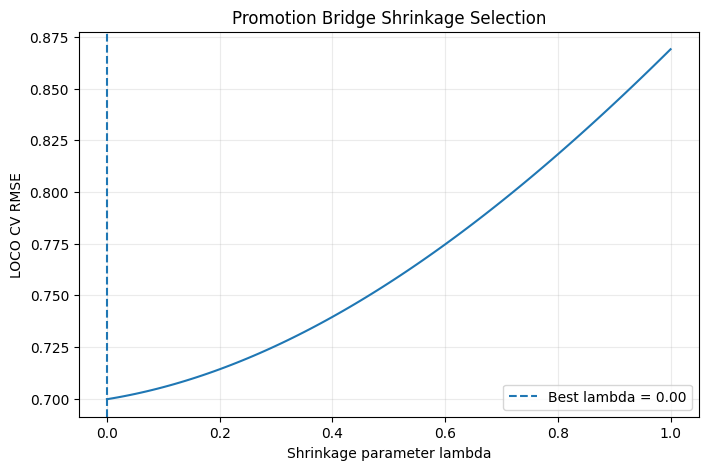

In [45]:
# ============================================================
# STEP 7 — Shrinkage Promotion Bridge
#
# q_EPL = mu + lambda * q_EFL
# 0 <= lambda <= 1
# ============================================================

lambda_grid = np.linspace(0, 1, 101)

results = []

cohorts = sorted(
    promotion_bridge["EPL_Season"].unique()
)

for lam in lambda_grid:

    all_errors = []

    for test_cohort in cohorts:

        train = promotion_bridge[
            promotion_bridge["EPL_Season"] != test_cohort
        ]

        test = promotion_bridge[
            promotion_bridge["EPL_Season"] == test_cohort
        ]

        # Given lambda, estimate intercept from training data
        mu_train = np.mean(
            train["q_EPL"] - lam * train["q_EFL"]
        )

        pred = (
            mu_train
            + lam * test["q_EFL"]
        )

        errors = test["q_EPL"].values - pred.values

        all_errors.extend(errors)

    rmse = np.sqrt(
        np.mean(np.array(all_errors) ** 2)
    )

    mae = np.mean(
        np.abs(all_errors)
    )

    results.append({
        "Lambda": lam,
        "CV_RMSE": rmse,
        "CV_MAE": mae
    })


shrinkage_cv = pd.DataFrame(results)

best_row = shrinkage_cv.loc[
    shrinkage_cv["CV_RMSE"].idxmin()
]

best_lambda = best_row["Lambda"]

# Refit on all historical promotion data
best_mu = np.mean(
    promotion_bridge["q_EPL"]
    - best_lambda * promotion_bridge["q_EFL"]
)

print("Best lambda:", round(best_lambda, 3))
print("Best mu:", round(best_mu, 4))
print("CV RMSE:", round(best_row["CV_RMSE"], 4))
print("CV MAE:", round(best_row["CV_MAE"], 4))

print(
    f"\nFinal bridge: "
    f"q_EPL = {best_mu:.4f} "
    f"+ {best_lambda:.3f} * q_EFL"
)


# Plot CV RMSE against lambda
plt.figure(figsize=(8, 5))

plt.plot(
    shrinkage_cv["Lambda"],
    shrinkage_cv["CV_RMSE"]
)

plt.axvline(
    best_lambda,
    linestyle="--",
    label=f"Best lambda = {best_lambda:.2f}"
)

plt.xlabel("Shrinkage parameter lambda")
plt.ylabel("LOCO CV RMSE")
plt.title("Promotion Bridge Shrinkage Selection")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

## 8. Testing Offseason Investment as an Additional Bridge Variable

A possible explanation for the weak persistence of Championship $q$ is that
promotion is followed by a major offseason transition.

Two clubs with similar Championship performance may enter the Premier League
with substantially different squads because of transfer activity.

Summer transfer expenditure is therefore introduced as an additional candidate
bridge variable.

To improve comparability across seasons, expenditure is represented by
`Expenditure_z`, which measures each club's log-transformed summer expenditure
relative to the other Premier League clubs in the same season.

The transfer data are merged using the EPL season entered after promotion.

This extension tests whether offseason investment explains some of the
team-level variation that Championship $q$ alone fails to capture.

In [46]:
# ============================================================
# STEP 8 — Merge summer transfer data into promotion bridge
# ============================================================

TRANSFER_FILE = "EPL_summer_transfers_2014_2025.xlsx"

transfer_data = pd.read_excel(
    TRANSFER_FILE
)

# Football-data names -> Transfermarkt names
team_name_map = {
    "Bournemouth": "AFC Bournemouth",
    "Norwich": "Norwich City",
    "Watford": "Watford FC",
    "Burnley": "Burnley FC",
    "Hull": "Hull City",
    "Middlesbrough": "Middlesbrough FC",
    "Brighton": "Brighton & Hove Albion",
    "Huddersfield": "Huddersfield Town",
    "Newcastle": "Newcastle United",
    "Cardiff": "Cardiff City",
    "Fulham": "Fulham FC",
    "Wolves": "Wolverhampton Wanderers",
    "West Brom": "West Bromwich Albion",
    "Brentford": "Brentford FC",
    "Nott'm Forest": "Nottingham Forest",
    "Luton": "Luton Town",
    "Ipswich": "Ipswich Town",
    "Leicester": "Leicester City",
    "Southampton": "Southampton FC",
    "Leeds": "Leeds United",
    "Sunderland": "Sunderland AFC"
}

promotion_bridge["Team_TM"] = (
    promotion_bridge["Team"]
    .replace(team_name_map)
)

bridge_transfer = promotion_bridge.merge(
    transfer_data[
        [
            "Season",
            "Team",
            "Summer_Expenditure_EUR_m",
            "Summer_Income_EUR_m",
            "Net_Spend_EUR_m",
            "Log_Expenditure",
            "Expenditure_z"
        ]
    ],
    left_on=["EPL_Season", "Team_TM"],
    right_on=["Season", "Team"],
    how="left",
    suffixes=("", "_TM")
)

display(
    bridge_transfer[
        [
            "Team",
            "EFL_Season",
            "q_EFL",
            "EPL_Season",
            "q_EPL",
            "Summer_Expenditure_EUR_m",
            "Net_Spend_EUR_m",
            "Expenditure_z"
        ]
    ]
)

print(
    "Missing transfer rows:",
    bridge_transfer["Expenditure_z"].isna().sum()
)

,Team,EFL_Season,q_EFL,EPL_Season,q_EPL,Summer_Expenditure_EUR_m,Net_Spend_EUR_m,Expenditure_z
0,Bournemouth,2014-15,1.643556,2015-16,-0.641302,31.00,31.00,-0.556766
1,Norwich,2014-15,1.405215,2015-16,-1.172952,15.80,7.56,-1.457166
2,Watford,2014-15,1.583970,2015-16,-0.441934,47.90,40.15,0.035773
3,Burnley,2015-16,1.950246,2016-17,-0.661554,24.70,24.70,-1.288407
4,Hull,2015-16,1.324499,2016-17,-0.971657,20.90,15.50,-1.544108
5,Middlesbrough,2015-16,1.699947,2016-17,-1.281761,28.75,19.35,-1.054545
6,Brighton,2016-17,1.811066,2017-18,-0.644885,52.00,51.60,-0.366632
7,Huddersfield,2016-17,1.072274,2017-18,-0.805438,44.40,38.55,-0.621267
8,Newcastle,2016-17,1.872632,2017-18,-0.430816,42.30,21.68,-0.699180
9,Cardiff,2017-18,1.621911,2018-19,-0.949914,30.75,30.75,-0.461759


Missing transfer rows: 0


## Step 9. Does Summer Investment Improve the Promotion Bridge?

The previous analysis showed that Championship strength alone provides little
stable information about a promoted club's next-season Premier League strength.

Summer transfer investment is now introduced as a candidate explanatory
variable.

Four nested models are compared:

$$
M_0:\quad q_{EPL}=\mu+\varepsilon,
$$

$$
M_1:\quad q_{EPL}=\alpha+\beta q_{EFL}+\varepsilon,
$$

$$
M_2:\quad q_{EPL}=\alpha+\gamma I+\varepsilon,
$$

$$
M_3:\quad
q_{EPL}
=
\alpha
+\beta q_{EFL}
+\gamma I
+\varepsilon,
$$

where $I$ is the season-standardized summer expenditure
(`Expenditure_z`).

All models are evaluated using Leave-One-Promotion-Cohort-Out cross-validation.
For each fold, all three promoted clubs entering the Premier League in the same
season are held out together.

In [27]:
# ============================================================
# STEP 9 — Compare promotion bridge models with LOCO CV
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error


df = bridge_transfer.copy()

# Make sure required variables are complete
required_cols = [
    "Team",
    "EPL_Season",
    "q_EFL",
    "q_EPL",
    "Expenditure_z"
]

print(df[required_cols].isna().sum())

assert df[required_cols].notna().all().all(), \
    "Missing values found in bridge model variables."


# ------------------------------------------------------------
# Model definitions
# ------------------------------------------------------------

model_specs = {
    "M0_Mean": [],
    "M1_EFL_q": ["q_EFL"],
    "M2_Investment": ["Expenditure_z"],
    "M3_EFL_q_Investment": [
        "q_EFL",
        "Expenditure_z"
    ]
}


# ------------------------------------------------------------
# Leave-One-Promotion-Cohort-Out CV
# ------------------------------------------------------------

prediction_rows = []

for held_out_season in sorted(df["EPL_Season"].unique()):

    train = df[
        df["EPL_Season"] != held_out_season
    ].copy()

    test = df[
        df["EPL_Season"] == held_out_season
    ].copy()

    y_train = train["q_EPL"].to_numpy()
    y_test = test["q_EPL"].to_numpy()

    for model_name, predictors in model_specs.items():

        # M0: training-sample mean only
        if len(predictors) == 0:

            pred = np.repeat(
                y_train.mean(),
                len(test)
            )

        # M1-M3: OLS regression
        else:

            model = LinearRegression()

            model.fit(
                train[predictors],
                y_train
            )

            pred = model.predict(
                test[predictors]
            )

        for idx, y_true, y_pred in zip(
            test.index,
            y_test,
            pred
        ):

            prediction_rows.append({
                "Model": model_name,
                "Held_Out_Season": held_out_season,
                "Team": df.loc[idx, "Team"],
                "Actual_q_EPL": y_true,
                "Predicted_q_EPL": y_pred
            })


cv_predictions = pd.DataFrame(
    prediction_rows
)


# ------------------------------------------------------------
# Overall out-of-sample performance
# ------------------------------------------------------------

results = []

for model_name in model_specs:

    temp = cv_predictions[
        cv_predictions["Model"] == model_name
    ]

    rmse = np.sqrt(
        mean_squared_error(
            temp["Actual_q_EPL"],
            temp["Predicted_q_EPL"]
        )
    )

    mae = mean_absolute_error(
        temp["Actual_q_EPL"],
        temp["Predicted_q_EPL"]
    )

    results.append({
        "Model": model_name,
        "CV_RMSE": rmse,
        "CV_MAE": mae
    })


cv_results = (
    pd.DataFrame(results)
    .sort_values("CV_RMSE")
    .reset_index(drop=True)
)

display(cv_results)

Team             0
EPL_Season       0
q_EFL            0
q_EPL            0
Expenditure_z    0
dtype: int64


,Model,CV_RMSE,CV_MAE
0,M0_Mean,0.699674,0.595544
1,M2_Investment,0.701514,0.603183
2,M1_EFL_q,0.724003,0.609317
3,M3_EFL_q_Investment,0.724010,0.618723


In [28]:
# ============================================================
# Full-sample coefficients for interpretation
# ============================================================

coef_rows = []

for model_name, predictors in model_specs.items():

    if len(predictors) == 0:

        coef_rows.append({
            "Model": model_name,
            "Intercept": df["q_EPL"].mean(),
            "Beta_q_EFL": np.nan,
            "Gamma_Investment": np.nan
        })

        continue

    model = LinearRegression()

    model.fit(
        df[predictors],
        df["q_EPL"]
    )

    row = {
        "Model": model_name,
        "Intercept": model.intercept_,
        "Beta_q_EFL": np.nan,
        "Gamma_Investment": np.nan
    }

    for feature, coef in zip(
        predictors,
        model.coef_
    ):

        if feature == "q_EFL":
            row["Beta_q_EFL"] = coef

        elif feature == "Expenditure_z":
            row["Gamma_Investment"] = coef

    coef_rows.append(row)


coefficient_table = pd.DataFrame(
    coef_rows
)

display(coefficient_table)

,Model,Intercept,Beta_q_EFL,Gamma_Investment
0,M0_Mean,-0.971347,NaN,NaN
1,M1_EFL_q,-0.768828,-0.116510,NaN
2,M2_Investment,-0.895834,NaN,0.188992
3,M3_EFL_q_Investment,-0.668315,-0.130244,0.191814


### Model-Comparison Result

The mean-only model achieves the lowest LOCO-CV error:

$$
RMSE_{M_0}=0.6997.
$$

Adding season-relative summer expenditure produces

$$
RMSE_{M_2}=0.7015,
$$

while models retaining Championship $q$ perform worse.

Although the fitted investment coefficient is positive, its inclusion does not
improve out-of-sample prediction.

Therefore, neither Championship relative strength nor summer expenditure
provides sufficient stable incremental information to justify a more complex
promotion bridge.

The mean-only specification is retained for the final initialization model.

## Step 10. Constructing the Promoted-Team Predictive Prior

The selected bridge is a mean-only model, but using a single fixed value for
every promoted team would ignore the substantial historical variation among
promoted clubs.

The final bridge is therefore represented probabilistically.

Across the 33 historical promotion transitions,

$$
\bar q_{EPL}=-0.971,
$$

with team-level standard deviation

$$
s=0.688.
$$

The standard error

$$
SE=\frac{s}{\sqrt{33}}\approx0.120
$$

describes uncertainty in the estimated population mean and should not be used
as the uncertainty of an individual promoted club.

Because the population mean and dispersion are estimated from a finite
historical sample, the EPL-scale strength of a new promoted team is represented
using a Student-$t$ posterior predictive distribution:

$$
q_{\mathrm{new},0}^{EPL}
\sim
t_{32}
(-0.971,\;0.698).
$$

Its 95% posterior predictive interval is approximately

$$
[-2.394,\;0.451].
$$

The wide interval reflects genuine historical heterogeneity among promoted
teams, even though the available preseason variables do not reliably identify
which promoted teams will lie at the stronger or weaker end of this range.

In [29]:
# ============================================================
# STEP 10 — Estimate promoted-team prior uncertainty
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import t


q_promoted = (
    bridge_transfer["q_EPL"]
    .dropna()
    .to_numpy()
)

n_promoted = len(q_promoted)

mu_promoted = np.mean(q_promoted)

sd_promoted = np.std(
    q_promoted,
    ddof=1
)

se_mean = (
    sd_promoted
    / np.sqrt(n_promoted)
)


print("Historical promoted teams:", n_promoted)
print("Prior center (sample mean):", mu_promoted)
print("Historical team-level SD:", sd_promoted)
print("SE of the mean:", se_mean)

Historical promoted teams: 33
Prior center (sample mean): -0.9713473791106279
Historical team-level SD: 0.6880882635679034
SE of the mean: 0.11978079201252703


In [30]:
# ============================================================
# STEP 10B — Posterior predictive distribution
# for a newly promoted team
# ============================================================

from scipy.stats import t

df_prior = n_promoted - 1

predictive_scale = (
    sd_promoted
    * np.sqrt(1 + 1 / n_promoted)
)

predictive_interval_95 = t.interval(
    0.95,
    df=df_prior,
    loc=mu_promoted,
    scale=predictive_scale
)

print("Degrees of freedom:", df_prior)
print("Predictive location:", mu_promoted)
print("Predictive scale:", predictive_scale)
print("95% predictive interval:", predictive_interval_95)

Degrees of freedom: 32
Predictive location: -0.9713473791106279
Predictive scale: 0.6984360361515152
95% predictive interval: (np.float64(-2.394015029421754), np.float64(0.45132027120049834))


In [33]:
# ============================================================
# STEP 10C — Gaussian approximation for dynamic updating
# ============================================================

initial_prior_mean = mu_promoted

initial_prior_sd = (
    predictive_scale
    * np.sqrt(
        df_prior / (df_prior - 2)
    )
)

initial_prior_var = initial_prior_sd ** 2

print("Initial prior mean:", initial_prior_mean)
print("Initial prior SD:", initial_prior_sd)
print("Initial prior variance:", initial_prior_var)

Initial prior mean: -0.9713473791106279
Initial prior SD: 0.7213416363749171
Initial prior variance: 0.5203337563680431


### Promoted-Team Predictive Prior

Across the 33 historical promotion transitions, the mean next-season
Premier League strength is

$$
\bar q_{EPL}=-0.971,
$$

with a team-level standard deviation of

$$
s=0.688.
$$

The standard error of the mean is substantially smaller,

$$
SE=\frac{s}{\sqrt{33}}\approx0.120,
$$

because it measures uncertainty in the estimated population mean rather than
variation among individual promoted clubs.

Since both the population mean and dispersion are estimated from a finite
historical sample, the preseason strength of a new promoted club is represented
using a Student-\(t\) posterior predictive distribution:

$$
q_{\mathrm{new},0}
\sim
t_{32}
\left(
-0.971,\,
0.698
\right).
$$

The corresponding 95% posterior predictive interval is approximately

$$
[-2.394,\ 0.451].
$$

This relatively wide interval reflects substantial historical heterogeneity
among promoted clubs. The bridge therefore provides a common prior center but
does not imply that all promoted teams have identical true strength.

## Step 11. Final EFL-to-EPL Bridge

The purpose of this bridge is to provide an EPL-scale value of the scalar
opponent-strength variable $q$ for teams entering the Premier League from the
Championship.

In the main seasonal-state model, opponent strength enters the
opponent-adjustment equation

$$
\mathbf{x}_{i,v,m}
=
\boldsymbol{\alpha}_{i,v}
+
\boldsymbol{\beta}_{i,v}q_{j(m)}
+
\boldsymbol{\varepsilon}_{i,v,m}.
$$

For established Premier League clubs, EPL-scale strength information can be
constructed directly from previous EPL seasons.

Newly promoted clubs do not have a previous EPL value of $q$. Their most
recent observed $q$ is measured on the Championship scale and therefore
cannot be inserted directly into the EPL model.

The promotion bridge fills this missing interface.

Historical promotion data show that neither Championship $q$ nor summer
transfer expenditure provides a stable team-specific mapping to next-season
EPL $q$. The final preseason initialization is therefore

$$
q_{\mathrm{promoted},0}^{EPL}
\sim
t_{32}
(-0.971,\;0.698).
$$

For subsequent Gaussian Bayesian or state-space computation, the same
predictive uncertainty can be approximated by

$$
q_{\mathrm{promoted},0}^{EPL}
\approx
N(-0.971,\;0.721^2).
$$

The bridge therefore does **not** transform the full venue-specific team state.
Its role is narrower: it calibrates the missing EPL-scale opponent-strength
input for newly promoted teams.

Once this initialization has been supplied, promoted clubs and established EPL
clubs can enter the same subsequent modeling framework.

This completes the EFL-to-EPL promotion bridge.

In [34]:
# ============================================================
# STEP 11 — Final bridge specification
# ============================================================

bridge_summary = pd.DataFrame({
    "Parameter": [
        "Historical_Promotion_Transitions",
        "Prior_Mean",
        "Historical_SD",
        "SE_of_Mean",
        "Predictive_df",
        "Predictive_Scale",
        "Gaussian_Prior_SD"
    ],
    "Value": [
        n_promoted,
        mu_promoted,
        sd_promoted,
        se_mean,
        df_prior,
        predictive_scale,
        initial_prior_sd
    ]
})

display(bridge_summary)

,Parameter,Value
0,Historical_Promotion_Transitions,33.000000
1,Prior_Mean,-0.971347
2,Historical_SD,0.688088
3,SE_of_Mean,0.119781
4,Predictive_df,32.000000
5,Predictive_Scale,0.698436
6,Gaussian_Prior_SD,0.721342


## Stage 2 — Promoted-Team Unified Strength Bridge

The existing EPL Bayesian prior is defined on the unified Strength Index \(S\), while promoted teams are observed in the Championship before promotion.

This stage therefore constructs a Championship-side strength measure using the same feature-weighting structure as the existing EPL Strength Index. The resulting Championship strength is still league-relative and will later be mapped onto the EPL \(S\) scale using historical promoted-team transitions.

The existing EPL strength definition is kept fixed rather than re-estimated.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Files
# ------------------------------------------------------------
STATE_FILE = Path("team_strength_all_results.xlsx")
STRENGTH_FILE = Path("strength_index_final_results.xlsx")

# ------------------------------------------------------------
# Load E1 baseline alpha
# ------------------------------------------------------------
alpha = pd.read_excel(
    STATE_FILE,
    sheet_name="Team_Baseline_Alpha"
)

e1_alpha = alpha[
    alpha["League"].eq("E1")
].copy()

# ------------------------------------------------------------
# Load the already-fixed EPL feature weights
# ------------------------------------------------------------
weights = pd.read_excel(
    STRENGTH_FILE,
    sheet_name="Final_Weights"
)

print("Feature weights:")
display(weights)

print("\nWeight sums:")
print(
    weights[
        ["Home_Weight", "Away_Weight"]
    ].sum()
)

# ------------------------------------------------------------
# Attach feature weights to E1 alpha
# ------------------------------------------------------------
e1_alpha = e1_alpha.merge(
    weights,
    on="Feature",
    how="left",
    validate="many_to_one"
)

if e1_alpha[
    ["Home_Weight", "Away_Weight"]
].isna().any().any():
    raise ValueError(
        "Some E1 features do not have matching Strength Index weights."
    )

# Venue-specific weight
e1_alpha["Weight"] = np.where(
    e1_alpha["Venue"].eq("Home"),
    e1_alpha["Home_Weight"],
    e1_alpha["Away_Weight"]
)

# Weighted contribution of each baseline-alpha coordinate
e1_alpha["Weighted_Alpha"] = (
    e1_alpha["Baseline_Alpha"]
    * e1_alpha["Weight"]
)

# ------------------------------------------------------------
# Collapse four features into venue-specific strength
# ------------------------------------------------------------
e1_venue_strength = (
    e1_alpha
    .groupby(
        ["Season", "Team", "Venue"],
        as_index=False
    )
    .agg(
        Strength_E1=("Weighted_Alpha", "sum"),
        N_Features=("Feature", "nunique")
    )
)

# Every team-season-venue should contain the same 4 features
if not e1_venue_strength["N_Features"].eq(4).all():
    raise ValueError(
        "At least one E1 team-season-venue does not contain all four features."
    )

print(
    "E1 venue-level strength rows:",
    len(e1_venue_strength)
)

display(
    e1_venue_strength.head(12)
)

Feature weights:


,Feature,Home_Weight,Away_Weight
0,Shot_Diff,0.297,0.286
1,SOT_Rate_Diff,0.287,0.175
2,Finishing_Diff,0.346,0.480
3,Corners_Diff,0.070,0.059



Weight sums:
Home_Weight    1.0
Away_Weight    1.0
dtype: float64
E1 venue-level strength rows: 240


,Season,Team,Venue,Strength_E1,N_Features
0,2021-22,Barnsley,Away,-0.400661,4
1,2021-22,Barnsley,Home,-0.163239,4
2,2021-22,Birmingham,Away,-0.259381,4
3,2021-22,Birmingham,Home,0.029505,4
4,2021-22,Blackburn,Away,0.011045,4
5,2021-22,Blackburn,Home,0.253734,4
6,2021-22,Blackpool,Away,-0.062250,4
7,2021-22,Blackpool,Home,0.014163,4
8,2021-22,Bournemouth,Away,0.205971,4
9,2021-22,Bournemouth,Home,0.314967,4


### 2.1 Championship Venue-Specific Strength

The Championship-side strength construction follows the same feature-weighting structure used for the existing EPL Strength Index.

For team $i$, season $t$, and venue $v$,

$$
S^{E1}_{i,t,v}
=
\sum_{k=1}^{4}
w_{v,k}\alpha_{i,t,v,k},
$$

where $\alpha_{i,t,v,k}$ is the opponent-adjusted baseline performance for feature $k$, and $w_{v,k}$ is the corresponding fixed feature weight previously estimated for the EPL strength model.

The EPL weights are reused rather than re-estimated for the Championship. This preserves the interpretation of the strength construction while avoiding a second independently fitted weighting system.

At this stage, the resulting Home and Away strength values remain Championship-side quantities and are not yet interpreted directly on the EPL unified-strength scale.

In [3]:
# ============================================================
# Pair E1 Home/Away strength and construct unified E1 scalar
# ============================================================

# ------------------------------------------------------------
# 1. Pair Home and Away strength
# ------------------------------------------------------------
e1_paired = (
    e1_venue_strength
    .pivot(
        index=["Season", "Team"],
        columns="Venue",
        values="Strength_E1"
    )
    .reset_index()
)

e1_paired = e1_paired.rename(
    columns={
        "Home": "Home_S_E1",
        "Away": "Away_S_E1"
    }
)

# Check completeness
if e1_paired[
    ["Home_S_E1", "Away_S_E1"]
].isna().any().any():
    raise ValueError(
        "Some E1 team-seasons are missing Home or Away strength."
    )

print("E1 paired team-season rows:", len(e1_paired))


# ------------------------------------------------------------
# 2. Pooled five-season standardization
#    Match the existing EPL PCA methodology
# ------------------------------------------------------------
home_mean_e1 = e1_paired["Home_S_E1"].mean()
away_mean_e1 = e1_paired["Away_S_E1"].mean()

home_sd_e1 = e1_paired["Home_S_E1"].std(ddof=0)
away_sd_e1 = e1_paired["Away_S_E1"].std(ddof=0)

if home_sd_e1 == 0 or away_sd_e1 == 0:
    raise ValueError(
        "E1 Home or Away strength has zero standard deviation."
    )

e1_paired["Home_Z_E1"] = (
    e1_paired["Home_S_E1"] - home_mean_e1
) / home_sd_e1

e1_paired["Away_Z_E1"] = (
    e1_paired["Away_S_E1"] - away_mean_e1
) / away_sd_e1


# ------------------------------------------------------------
# 3. Unified Championship-side strength direction
# ------------------------------------------------------------
e1_paired["S_E1"] = (
    e1_paired["Home_Z_E1"]
    +
    e1_paired["Away_Z_E1"]
) / np.sqrt(2)

# Optional Home/Away asymmetry coordinate
e1_paired["Venue_Asymmetry_E1"] = (
    e1_paired["Home_Z_E1"]
    -
    e1_paired["Away_Z_E1"]
) / np.sqrt(2)


# ------------------------------------------------------------
# 4. Diagnostics
# ------------------------------------------------------------
corr_e1 = e1_paired[
    ["Home_Z_E1", "Away_Z_E1"]
].corr().iloc[0, 1]

print("\nPooled E1 standardization")
print("-------------------------")
print(f"Home mean = {home_mean_e1:.6f}")
print(f"Home SD   = {home_sd_e1:.6f}")
print(f"Away mean = {away_mean_e1:.6f}")
print(f"Away SD   = {away_sd_e1:.6f}")
print(f"Home/Away correlation = {corr_e1:.4f}")

print("\nChecks")
print("------")
print(
    "Home_Z mean:",
    e1_paired["Home_Z_E1"].mean()
)
print(
    "Away_Z mean:",
    e1_paired["Away_Z_E1"].mean()
)
print(
    "Home_Z variance:",
    e1_paired["Home_Z_E1"].var(ddof=0)
)
print(
    "Away_Z variance:",
    e1_paired["Away_Z_E1"].var(ddof=0)
)


# ------------------------------------------------------------
# 5. Inspect 2025-26 promoted teams
# ------------------------------------------------------------
PROMOTED_2026_27 = [
    "Coventry",
    "Ipswich",
    "Hull"
]

promoted_e1_strength = (
    e1_paired[
        (e1_paired["Season"].astype(str) == "2025-26")
        &
        (e1_paired["Team"].isin(PROMOTED_2026_27))
    ]
    .sort_values("S_E1", ascending=False)
    .reset_index(drop=True)
)

print("\n2025-26 Championship strength of 2026-27 promoted teams:")
display(
    promoted_e1_strength[
        [
            "Season",
            "Team",
            "Home_S_E1",
            "Away_S_E1",
            "Home_Z_E1",
            "Away_Z_E1",
            "S_E1",
            "Venue_Asymmetry_E1"
        ]
    ]
)

E1 paired team-season rows: 120

Pooled E1 standardization
-------------------------
Home mean = 0.135120
Home SD   = 0.187087
Away mean = -0.135880
Away SD   = 0.199896
Home/Away correlation = 0.6645

Checks
------
Home_Z mean: -1.0362081563168128e-16
Away_Z mean: -2.3869795029440865e-16
Home_Z variance: 1.0
Away_Z variance: 1.0000000000000002

2025-26 Championship strength of 2026-27 promoted teams:


Venue,Season,Team,Home_S_E1,Away_S_E1,Home_Z_E1,Away_Z_E1,S_E1,Venue_Asymmetry_E1
0,2025-26,Ipswich,0.483734,0.109172,1.863380,1.225895,2.184447,0.450770
1,2025-26,Coventry,0.420899,0.145592,1.527521,1.408089,2.075790,0.084451
2,2025-26,Hull,0.063495,-0.150661,-0.382849,-0.073943,-0.323001,-0.218429


### 2.2 Unified Championship Strength

Home and Away strength are paired at the team-season level and standardized using the pooled five-season Championship sample:

$$
Z^{E1}_{H}
=
\frac{S^{E1}_{H}-\mu^{E1}_{H}}
{\sigma^{E1}_{H}},
$$

$$
Z^{E1}_{A}
=
\frac{S^{E1}_{A}-\mu^{E1}_{A}}
{\sigma^{E1}_{A}}.
$$

To remain consistent with the previously selected EPL PCA direction, the Championship-side unified strength scalar is defined as

$$
S^{E1}
=
\frac{
Z^{E1}_{H}+Z^{E1}_{A}
}
{\sqrt{2}}.
$$

The Home/Away correlation in the Championship sample is approximately

$$
r=0.665,
$$

indicating a substantial common strength component across venues.

For the 2025-26 Championship season, the promoted clubs obtain:

$$
S^{E1}_{Ipswich}=2.184,
$$

$$
S^{E1}_{Coventry}=2.076,
$$

$$
S^{E1}_{Hull}=-0.323.
$$

These values describe relative strength within the Championship environment only. They cannot yet be inserted directly as EPL Bayesian prior means because the competitive reference scale differs between the two leagues.

In [5]:
# ============================================================
# Historical promotion bridge pairs:
# Championship S_E1  ->  next-season EPL S
# ============================================================

# ------------------------------------------------------------
# 1. Historical promotion map
# ------------------------------------------------------------
promotion_map = pd.DataFrame([
    ["2021-22", "Fulham",           "2022-23", "Automatic"],
    ["2021-22", "Bournemouth",      "2022-23", "Automatic"],
    ["2021-22", "Nott'm Forest",    "2022-23", "Play-off"],

    ["2022-23", "Burnley",          "2023-24", "Automatic"],
    ["2022-23", "Sheffield United", "2023-24", "Automatic"],
    ["2022-23", "Luton",            "2023-24", "Play-off"],

    ["2023-24", "Leicester",        "2024-25", "Automatic"],
    ["2023-24", "Ipswich",          "2024-25", "Automatic"],
    ["2023-24", "Southampton",      "2024-25", "Play-off"],

    ["2024-25", "Leeds",            "2025-26", "Automatic"],
    ["2024-25", "Burnley",          "2025-26", "Automatic"],
    ["2024-25", "Sunderland",       "2025-26", "Play-off"],

    ["2025-26", "Coventry",         "2026-27", "Automatic"],
    ["2025-26", "Ipswich",          "2026-27", "Automatic"],
    ["2025-26", "Hull",             "2026-27", "Play-off"],
], columns=[
    "Championship_Season",
    "Team",
    "EPL_Season",
    "Promotion_Route"
])


# ------------------------------------------------------------
# 2. Attach Championship-side S_E1
# ------------------------------------------------------------
promotion_pairs = promotion_map.merge(
    e1_paired[
        ["Season", "Team", "S_E1"]
    ].rename(
        columns={
            "Season": "Championship_Season"
        }
    ),
    on=["Championship_Season", "Team"],
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 3. Load the existing final EPL unified S
# ------------------------------------------------------------
# Use the Bayesian-ready S file you already created.
epl_s = pd.read_csv(
    "bayesian_strength_input.csv"
)

print("EPL S columns:")
print(epl_s.columns.tolist())

display(epl_s.head())

EPL S columns:
['Season', 'Team', 'Home_S', 'Away_S', 'S', 'V']


,Season,Team,Home_S,Away_S,S,V
0,2021-22,Arsenal,0.281840,-0.134862,0.435698,0.746632
1,2021-22,Aston Villa,0.136996,0.011685,0.467211,-0.143943
2,2021-22,Brentford,-0.005392,-0.147406,-0.455542,-0.065680
3,2021-22,Brighton,-0.077576,0.031160,-0.107825,-0.841515
4,2021-22,Burnley,-0.142987,-0.279384,-1.278786,-0.058503


In [6]:
# ============================================================
# Build historical promoted-team E1 -> EPL strength pairs
# ============================================================

# Only cohorts for which next-season EPL S is already observed
historical_promotions = promotion_pairs[
    promotion_pairs["EPL_Season"] != "2026-27"
].copy()

# Attach next-season realized EPL unified strength S
historical_pairs = historical_promotions.merge(
    epl_s[
        ["Season", "Team", "S"]
    ].rename(
        columns={
            "Season": "EPL_Season",
            "S": "S_EPL"
        }
    ),
    on=["EPL_Season", "Team"],
    how="left",
    validate="one_to_one"
)

# Check whether anything failed to match
missing = historical_pairs[
    historical_pairs[["S_E1", "S_EPL"]].isna().any(axis=1)
]

if len(missing) > 0:
    print("Unmatched promoted-team rows:")
    display(missing)
    raise ValueError(
        "Some historical promoted teams could not be matched."
    )

print("Historical promotion pairs:", len(historical_pairs))

display(
    historical_pairs[
        [
            "Championship_Season",
            "Team",
            "Promotion_Route",
            "S_E1",
            "EPL_Season",
            "S_EPL"
        ]
    ]
    .sort_values(
        ["Championship_Season", "Team"]
    )
    .reset_index(drop=True)
)

# Preliminary correlation only
corr_bridge = historical_pairs[
    ["S_E1", "S_EPL"]
].corr().iloc[0, 1]

print(
    f"\nCorrelation between Championship S_E1 "
    f"and next-season EPL S = {corr_bridge:.4f}"
)

Historical promotion pairs: 12


,Championship_Season,Team,Promotion_Route,S_E1,EPL_Season,S_EPL
0,2021-22,Bournemouth,Automatic,1.888993,2022-23,-1.709464
1,2021-22,Fulham,Automatic,2.691540,2022-23,0.085858
2,2021-22,Nott'm Forest,Play-off,1.169789,2022-23,-1.453462
3,2022-23,Burnley,Automatic,2.884855,2023-24,-2.110267
4,2022-23,Luton,Play-off,0.903749,2023-24,-0.881559
5,2022-23,Sheffield United,Automatic,2.219415,2023-24,-2.987599
6,2023-24,Ipswich,Automatic,1.498751,2024-25,-1.928187
7,2023-24,Leicester,Automatic,2.291439,2024-25,-2.305093
8,2023-24,Southampton,Play-off,1.410885,2024-25,-3.134512
9,2024-25,Burnley,Automatic,3.269048,2025-26,-2.088381



Correlation between Championship S_E1 and next-season EPL S = 0.1071


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ============================================================
# Leave-One-Promotion-Cohort-Out CV
# Compare:
# M0: constant mean
# M1: linear S_EPL = a + b * S_E1
# ============================================================

cohorts = sorted(
    historical_pairs["Championship_Season"].unique()
)

cv_rows = []
prediction_rows = []

for test_cohort in cohorts:

    train = historical_pairs[
        historical_pairs["Championship_Season"] != test_cohort
    ].copy()

    test = historical_pairs[
        historical_pairs["Championship_Season"] == test_cohort
    ].copy()

    # --------------------------------------------------------
    # M0: constant model
    # --------------------------------------------------------
    constant_pred = train["S_EPL"].mean()

    pred_m0 = np.repeat(
        constant_pred,
        len(test)
    )

    # --------------------------------------------------------
    # M1: linear model
    # --------------------------------------------------------
    linear_model = LinearRegression()

    linear_model.fit(
        train[["S_E1"]],
        train["S_EPL"]
    )

    pred_m1 = linear_model.predict(
        test[["S_E1"]]
    )

    # --------------------------------------------------------
    # Fold metrics
    # --------------------------------------------------------
    rmse_m0 = np.sqrt(
        mean_squared_error(
            test["S_EPL"],
            pred_m0
        )
    )

    rmse_m1 = np.sqrt(
        mean_squared_error(
            test["S_EPL"],
            pred_m1
        )
    )

    mae_m0 = mean_absolute_error(
        test["S_EPL"],
        pred_m0
    )

    mae_m1 = mean_absolute_error(
        test["S_EPL"],
        pred_m1
    )

    cv_rows.append({
        "Held_Out_Cohort": test_cohort,
        "Intercept_Linear": linear_model.intercept_,
        "Slope_Linear": linear_model.coef_[0],
        "RMSE_Constant": rmse_m0,
        "RMSE_Linear": rmse_m1,
        "MAE_Constant": mae_m0,
        "MAE_Linear": mae_m1
    })

    # Save individual out-of-sample predictions
    temp = test[
        [
            "Championship_Season",
            "Team",
            "S_E1",
            "S_EPL"
        ]
    ].copy()

    temp["Pred_Constant"] = pred_m0
    temp["Pred_Linear"] = pred_m1

    prediction_rows.append(temp)


cv_results = pd.DataFrame(cv_rows)

cv_predictions = pd.concat(
    prediction_rows,
    ignore_index=True
)

print("LOCO-CV results:")
display(cv_results)

print("\nOverall out-of-sample performance")
print("---------------------------------")

overall_rmse_m0 = np.sqrt(
    mean_squared_error(
        cv_predictions["S_EPL"],
        cv_predictions["Pred_Constant"]
    )
)

overall_rmse_m1 = np.sqrt(
    mean_squared_error(
        cv_predictions["S_EPL"],
        cv_predictions["Pred_Linear"]
    )
)

overall_mae_m0 = mean_absolute_error(
    cv_predictions["S_EPL"],
    cv_predictions["Pred_Constant"]
)

overall_mae_m1 = mean_absolute_error(
    cv_predictions["S_EPL"],
    cv_predictions["Pred_Linear"]
)

print(f"Constant RMSE = {overall_rmse_m0:.4f}")
print(f"Linear   RMSE = {overall_rmse_m1:.4f}")

print(f"Constant MAE  = {overall_mae_m0:.4f}")
print(f"Linear   MAE  = {overall_mae_m1:.4f}")

print("\nOut-of-sample predictions:")
display(
    cv_predictions.sort_values(
        ["Championship_Season", "Team"]
    ).reset_index(drop=True)
)

LOCO-CV results:


,Held_Out_Cohort,Intercept_Linear,Slope_Linear,RMSE_Constant,RMSE_Linear,MAE_Constant,MAE_Linear
0,2021-22,-1.917826,0.049656,1.114833,1.106828,0.783685,0.796957
1,2022-23,-2.084499,0.277259,1.001192,1.139349,0.909806,1.098813
2,2023-24,-1.280822,-0.023075,1.231147,1.243066,1.123304,1.135104
3,2024-25,-1.895659,0.037539,1.153742,1.137087,1.021511,1.021199



Overall out-of-sample performance
---------------------------------
Constant RMSE = 1.1283
Linear   RMSE = 1.1577
Constant MAE  = 0.9596
Linear   MAE  = 1.0130

Out-of-sample predictions:


,Championship_Season,Team,S_E1,S_EPL,Pred_Constant,Pred_Linear
0,2021-22,Bournemouth,1.888993,-1.709464,-1.809374,-1.824026
1,2021-22,Fulham,2.691540,0.085858,-1.809374,-1.784174
2,2021-22,Nott'm Forest,1.169789,-1.453462,-1.809374,-1.859738
3,2022-23,Burnley,2.884855,-2.110267,-1.486890,-1.284648
4,2022-23,Luton,0.903749,-0.881559,-1.486890,-1.833927
5,2022-23,Sheffield United,2.219415,-2.987599,-1.486890,-1.469147
6,2023-24,Ipswich,1.498751,-1.928187,-1.332627,-1.315405
7,2023-24,Leicester,2.291439,-2.305093,-1.332627,-1.333696
8,2023-24,Southampton,1.410885,-3.134512,-1.332627,-1.313378
9,2024-25,Burnley,3.269048,-2.088381,-1.824921,-1.772941


### 2.3 Mapping Championship Strength to the EPL Scale

Historical promoted clubs are used to test whether Championship-side unified strength contains stable information about next-season EPL strength.

For each historical promotion transition, the pair

$$
\left(
S^{E1}_{i,t},
S^{EPL}_{i,t+1}
\right)
$$

is constructed.

Twelve historical transitions are available across four promotion cohorts.

The raw correlation is weak:

$$
r
\left(
S^{E1}_{t},
S^{EPL}_{t+1}
\right)
\approx
0.107.
$$

Twelve recent promotion transitions are available across four promotion cohorts, covering Championship seasons from 2021-22 to 2024-25.

Although a longer historical window was available for the earlier PPG-based opponent-strength bridge, the final unified Strength Index $S$ was constructed only for the recent five-season state-estimation window. Therefore, the present bridge deliberately uses the 12 promotion transitions for which both Championship-side and subsequent EPL strength can be reconstructed under the same final model specification.

This prioritizes methodological consistency over a larger but differently constructed historical sample.

**Constant model**

$$
M_0:
\qquad
S^{EPL}_{i,t+1}
=
a+\varepsilon_i,
$$

and **linear model**

$$
M_1:
\qquad
S^{EPL}_{i,t+1}
=
a+bS^{E1}_{i,t}+\varepsilon_i.
$$

Model selection is based on leave-one-promotion-cohort-out cross-validation. In each fold, all three promoted teams from one Championship season are held out together, preventing teams from the same promotion cohort from appearing simultaneously in the training and validation samples.

The out-of-sample results are:

$$
RMSE_{constant}=1.1283,
\qquad
RMSE_{linear}=1.1577,
$$

and

$$
MAE_{constant}=0.9596,
\qquad
MAE_{linear}=1.0130.
$$

The estimated linear slope is also unstable across held-out cohorts, ranging approximately from

$$
-0.023
\quad \text{to} \quad
0.277.
$$

Therefore, Championship relative strength does not provide sufficiently stable out-of-sample information for estimating team-specific EPL strength at promotion.

The simpler constant bridge is retained.

Extending the unified-strength bridge to older promotion cohorts is left as a possible robustness extension.

In [8]:
# ============================================================
# Final promoted-team mean bridge
# ============================================================

# Constant model fitted using all 12 historical promotion cases
promoted_mean_S = historical_pairs["S_EPL"].mean()

# Diagnostic dispersion only
promoted_sd_S = historical_pairs["S_EPL"].std(ddof=1)

print("Final promoted-team constant bridge")
print("-----------------------------------")
print(f"Mean EPL S = {promoted_mean_S:.6f}")
print(f"Historical SD = {promoted_sd_S:.6f}")


# ------------------------------------------------------------
# 2026-27 promoted teams
# ------------------------------------------------------------
target_promoted = promotion_pairs[
    promotion_pairs["EPL_Season"] == "2026-27"
].copy()

target_promoted["Prior_Mean_S"] = promoted_mean_S
target_promoted["Bridge_Model"] = "Constant mean"

promoted_prior_mean = target_promoted[
    [
        "Team",
        "Championship_Season",
        "S_E1",
        "Prior_Mean_S",
        "Promotion_Route",
        "Bridge_Model"
    ]
].copy()

display(
    promoted_prior_mean.sort_values("Team").reset_index(drop=True)
)

Final promoted-team constant bridge
-----------------------------------
Mean EPL S = -1.613453
Historical SD = 1.024187


,Team,Championship_Season,S_E1,Prior_Mean_S,Promotion_Route,Bridge_Model
0,Coventry,2025-26,2.075790,-1.613453,Automatic,Constant mean
1,Hull,2025-26,-0.323001,-1.613453,Play-off,Constant mean
2,Ipswich,2025-26,2.184447,-1.613453,Automatic,Constant mean


### 2.4 Final Promoted-Team Prior Mean

Because the linear mapping does not improve out-of-sample prediction, the final promoted-team bridge uses the pooled mean EPL strength observed across the twelve historical promotion transitions:

$$
\mu_{promoted}
=
\frac{1}{12}
\sum_{i=1}^{12}
S^{EPL}_i
=
-1.613.
$$

Therefore, the 2026-27 promoted clubs receive the common preseason prior mean

$$
\mu_{Coventry,0}
=
\mu_{Ipswich,0}
=
\mu_{Hull,0}
=
-1.613.
$$

This does not imply that the three clubs are assumed to have identical true strength. Rather, the historical sample does not support a stable team-specific mapping from Championship relative strength to next-season EPL strength.

Their preseason uncertainty will still differ through the team-specific instability multiplier \(M_i\) in the Bayesian prior variance:

$$
P_{i,0}
=
Q_0M_i.
$$

The historical standard deviation of promoted-team EPL strength,

$$
SD(S^{EPL}_{promoted})
=
1.024,
$$

is reported as a descriptive measure of historical heterogeneity only. It is **not added separately to the Bayesian prior variance**, because preseason uncertainty is calibrated independently through $Q_0M_i$.

The final promoted-team Bayesian initialization therefore takes the form

$$
\boxed{
\theta_{i,0}
\sim
\mathcal{N}
\left(
-1.613,\,
Q_0M_i
\right)
}
$$

for each newly promoted club.
This estimate should be interpreted as a recent-sample calibration rather than a universal long-run promotion effect, since the unified Strength Index is available under the final specification only for the recent five-season window.

In [9]:
promoted_prior_mean.to_csv(
    "promoted_prior_mean_2026_27.csv",
    index=False
)

print("Saved: promoted_prior_mean_2026_27.csv")

Saved: promoted_prior_mean_2026_27.csv
